Use Google Drive to get your provided files.

> Blok alıntı ekle



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Change the execution directory of the notebook, so you can import files without bothering with finding path.

In [2]:
import os

p1_lab = '/content/drive/MyDrive/UPF_Deep_Learning_2025/P1/' # your path if changed, but we recommend to keep it consistent for our ease.
os.chdir(p1_lab)

Now we can access everything easily.

# Ex. 1


## Steps
1. Download the breast cancer dataset using sci-kit-learn, following https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html.
Split into train and test datasets. Prepare the dataset as we discussed in the session.

  _Note: Use the first 10 features only as others are statistical add-ons._
2. Visualize two features as explained in the session: `radius`, and `texture`.
3. Using `Numpy`, implement the training process of a basic Multi-Layer Perceptron (MLP) to solve the binary classification problem.
4. Implement a training with validation phase and record both training and validation losses through iterations.
5. Plot a figure showing the training loss and validation loss together. This will be your baseline performance plot.
6. Compute test accuracy
7. Plot model's predicted datapoints for features from 2nd step and compare for test dataset (using KDE plot overlay by `seaborn`, code is provided).  

## Sol. 1

In [3]:
# !pip install sklearn # if necessary, uncomment.

In [4]:
# all needed import
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple
import seaborn as sns
import torch
import torch.nn as nn



In [5]:
# Choose your Drive folder once
save_folder = "/content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results"
os.makedirs(save_folder, exist_ok=True)

def save_current_figure(filename, folder=save_folder, dpi=300):
    """
    Save the current matplotlib figure to the specified Drive folder.

    Parameters:
        filename (str): file name without extension or with .png/.pdf
        folder (str): destination folder
        dpi (int): image quality
    """
    if not (filename.endswith(".png") or filename.endswith(".pdf") or filename.endswith(".jpg")):
        filename += ".png"

    full_path = os.path.join(folder, filename)
    plt.savefig(full_path, dpi=dpi, bbox_inches="tight")
    print(f"Figure saved to: {full_path}")

In [6]:
data = load_breast_cancer()
data.feature_names
data.data.shape

(569, 30)

We provide you a default split for dataset (to easily compare your results during grading). **Do not change random_state here**. In fact, do not change any of the code block we provide. Add yours on top of them.

In [7]:
# Load dataset
data = load_breast_cancer()
X = data.data  # Features
y = data.target  # Target labels
num_samples = X.shape[0]

# Split the data into 85% training and 15% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Expand dims to be compatible (column vector instead of 1D array)
y_train, y_test = np.expand_dims(y_train, axis=1), np.expand_dims(y_test, axis=1)

# Print shapes to verify
print("Training set shape:", s:=X_train.shape, y_train.shape, round(s[0] / num_samples, 2))
print("Testing set shape:", s:=X_test.shape, y_test.shape, round(s[0] / num_samples, 2))

Training set shape: (483, 30) (483, 1) 0.85
Testing set shape: (86, 30) (86, 1) 0.15


In [8]:
# Create a DataFrame for features X with actual feature names
X_df = pd.DataFrame(X, columns=data.feature_names)
print("First 5 rows of features (X) with names:")
display(X_df.head())

# Create a DataFrame for target labels y
y_df = pd.DataFrame(y, columns=['Target'])
print("\nFirst 5 rows of target labels (y) with name:")
display(y_df.head())

First 5 rows of features (X) with names:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First 5 rows of target labels (y) with name:


,Target
0,0
1,0
2,0
3,0
4,0


In [9]:
# Prepare the dataset: split into 70% training, 15% validation, and 15% testing
X_train = X_train[:, :10]
X_test = X_test[:, :10]

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15/0.85,
    random_state=42,
    stratify=y_train
)

mean = X_train_sub.mean(axis=0)
std = X_train_sub.std(axis=0)

X_train_sub = (X_train_sub - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Print shapes to verify
print("Training set shape:", s:=X_train_sub.shape, y_train.shape, round(s[0] / num_samples, 2))
print("Validation set shape:", s:=X_val.shape, y_train.shape, round(s[0] / num_samples, 2))
print("Testing set shape:", s:=X_test.shape, y_test.shape, round(s[0] / num_samples, 2))

Training set shape: (397, 10) (483, 1) 0.7
Validation set shape: (86, 10) (483, 1) 0.15
Testing set shape: (86, 10) (86, 1) 0.15


Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/radius_vs_texture.png


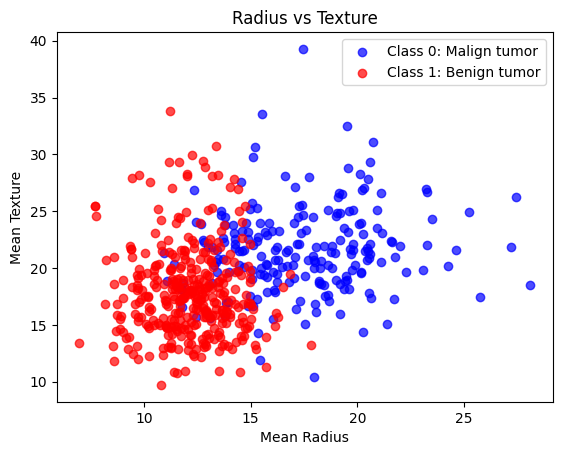

In [10]:
# Visualize two features: radius and texture

# Extract features
radius = X[:, 0]   # mean radius
texture = X[:, 1]  # mean texture

# Scatter plot by class
plt.figure()
plt.scatter(radius[y == 0], texture[y == 0], color="blue", alpha=0.7, label="Class 0: Malign tumor")
plt.scatter(radius[y == 1], texture[y == 1], color="red", alpha=0.7, label="Class 1: Benign tumor")

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Radius vs Texture")
plt.legend()
save_current_figure("radius_vs_texture")
plt.show()

**Figure 1.1** We have plot the radius and texture features from the dataset, which correspond to dimensions 0 and 1 of X data. We have seen that malign tumors tend to have a higher radius and texture than benign tumors.


In [11]:
# Using `Numpy`, implement the training process of a basic Multi-Layer Perceptron (MLP) to solve the binary classification problem.
#LOSS function = l2
class MLP:
    """
    A simple implementation of a Multi-Layer Perceptron (MLP) with one hidden layer.

    Attributes:
        inputLayerSize (int): Number of neurons in the input layer.
        outputLayerSize (int): Number of neurons in the output layer.
        hiddenLayerSize (int): Number of neurons in the hidden layer.
        W1 (np.ndarray): Weight matrix from input layer to hidden layer.
        W2 (np.ndarray): Weight matrix from hidden layer to output layer.

    Methods:
        forward(X): Performs forward propagation to predict the output.
        sigmoid(z): The sigmoid activation function.
        sigmoidPrime(z): Derivative of the sigmoid function.
        loss(yHat, y): Calculates the mean squared error loss.
        backward(X, yHat, y): Performs backpropagation, computing gradients with respect to W1 and W2.
    """

    def __init__(self, inputNode: int = 2, hiddenNode: int = 3, outputNode: int = 1) -> None:
        """
        Initializes the MLP model with random weights.

        Parameters:
            inputNode (int): Number of input dimensions.
            hiddenNode (int): Number of hidden neurons.
            outputNode (int): Number of output dimensions.
        """
        self.inputLayerSize = inputNode
        self.outputLayerSize = outputNode
        self.hiddenLayerSize = hiddenNode
        self.W1 = np.random.randn(self.inputLayerSize, self.hiddenLayerSize)
        self.W2 = np.random.randn(self.hiddenLayerSize, self.outputLayerSize)
        self.b1 = np.zeros((1, self.hiddenLayerSize))
        self.b2 = np.zeros((1, self.outputLayerSize))

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Forward propagation through the network.

        Parameters:
            X (np.ndarray): Input data.

        Returns:
            np.ndarray: The predicted output.
        """
        self.z2 = np.dot(X, self.W1) + self.b1
        self.a2 = self.sigmoid(self.z2)
        self.z3 = np.dot(self.a2, self.W2) + self.b2
        yHat = self.sigmoid(self.z3)
        return yHat

    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        """
        Applies the sigmoid activation function.

        Parameters:
            z (np.ndarray): Input to the activation function.

        Returns:
            np.ndarray: The activated output.
        """
        return 1 / (1 + np.exp(-z))

    def sigmoidPrime(self, z: np.ndarray) -> np.ndarray:
        """
        Computes the derivative of the sigmoid function.

        Parameters:
            z (np.ndarray): Input to the activation function.

        Returns:
            np.ndarray: The derivative of the sigmoid function at z.
        """
        sigmoid_z = self.sigmoid(z)
        return sigmoid_z * (1 - sigmoid_z)

    def loss(self, yHat: np.ndarray, y: np.ndarray) -> np.float64:
        """
        Calculates the entropy loss which is better for when you have a binary outcome.

        Parameters:
            yHat (np.ndarray): Predicted output.
            y (np.ndarray): Actual output.

        Returns:
            np.float64: The calculated loss.
        """
        return -np.mean(
            y * np.log(yHat + 1e-8) +
            (1 - y) * np.log(1 - yHat + 1e-8)
        )


    def backward(self, X: np.ndarray, yHat: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Backpropagation algorithm to compute the gradients of the loss function with respect to the weights.

        Parameters:
            X (np.ndarray): Input data.
            yHat (np.ndarray): Predicted output.
            y (np.ndarray): Actual output.

        Returns:
            Tuple[np.ndarray, np.ndarray]: Gradients of the loss function with respect to W1 and W2.
        """
        batch_size = y.shape[0]
        delta3 = (yHat - y)  / batch_size
        dJdW2 = np.dot(self.a2.T, delta3)
        dJdb2 = np.sum(delta3, axis=0, keepdims=True)

        delta2 = np.dot(delta3, self.W2.T) * self.sigmoidPrime(self.z2)
        dJdW1 = np.dot(X.T, delta2)
        dJdb1 = np.sum(delta2, axis=0, keepdims=True)


        return dJdW1, dJdW2, dJdb1, dJdb2

In [12]:
# Implement a training with validation phase and record both training and validation losses through iterations.
def train(NN: MLP,
          X_train: np.ndarray,
          y_train: np.ndarray,
          X_val: np.ndarray,
          y_val: np.ndarray,
          epoch: int = 10000,
          lr: float = 0.1):
    """
    Trains a Multi-Layer Perceptron using gradient descent
    and records training and validation losses.

    Parameters:
        NN (MLP): The MLP instance to be trained.
        X_train (np.ndarray): Training features.
        y_train (np.ndarray): Training labels.
        X_val (np.ndarray): Validation features.
        y_val (np.ndarray): Validation labels.
        epoch (int): Number of training iterations.
        lr (float): Learning rate.

    Returns:
        train_losses, val_losses: lists of loss values.
    """
    train_losses = []
    val_losses = []

    for i in range(epoch):
        # Forward pass on training set
        yHat_train = NN.forward(X_train)

        # Compute gradients
        gradW1, gradW2, gradb1, gradb2 = NN.backward(X_train, yHat_train, y_train)

        # Update parameters
        NN.W1 -= lr * gradW1
        NN.W2 -= lr * gradW2
        NN.b1 -= lr * gradb1
        NN.b2 -= lr * gradb2

        # Compute training loss
        train_loss = NN.loss(yHat_train, y_train)

        # Forward pass on validation set
        yHat_val = NN.forward(X_val)
        val_loss = NN.loss(yHat_val, y_val)

        # Store losses
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Print every 100 epochs
        if i % 100 == 0:
            print(f"Epoch {i}: train loss = {train_loss:.4f}, validation loss = {val_loss:.4f}")

    return train_losses, val_losses

In [13]:
mlp = MLP(inputNode=X_train.shape[1], hiddenNode=3, outputNode=1)

train_losses, val_losses = train(
    mlp,
    X_train_sub,
    y_train_sub,
    X_val,
    y_val,
    epoch=2000,
    lr=0.1
)

Epoch 0: train loss = 0.8565, validation loss = 0.8161
Epoch 100: train loss = 0.3827, validation loss = 0.3872
Epoch 200: train loss = 0.3085, validation loss = 0.3050
Epoch 300: train loss = 0.2610, validation loss = 0.2498
Epoch 400: train loss = 0.2286, validation loss = 0.2092
Epoch 500: train loss = 0.2067, validation loss = 0.1793
Epoch 600: train loss = 0.1917, validation loss = 0.1579
Epoch 700: train loss = 0.1812, validation loss = 0.1427
Epoch 800: train loss = 0.1735, validation loss = 0.1319
Epoch 900: train loss = 0.1678, validation loss = 0.1240
Epoch 1000: train loss = 0.1635, validation loss = 0.1181
Epoch 1100: train loss = 0.1603, validation loss = 0.1136
Epoch 1200: train loss = 0.1578, validation loss = 0.1099
Epoch 1300: train loss = 0.1559, validation loss = 0.1070
Epoch 1400: train loss = 0.1543, validation loss = 0.1045
Epoch 1500: train loss = 0.1530, validation loss = 0.1025
Epoch 1600: train loss = 0.1519, validation loss = 0.1008
Epoch 1700: train loss = 0

Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/baseline_performance.png


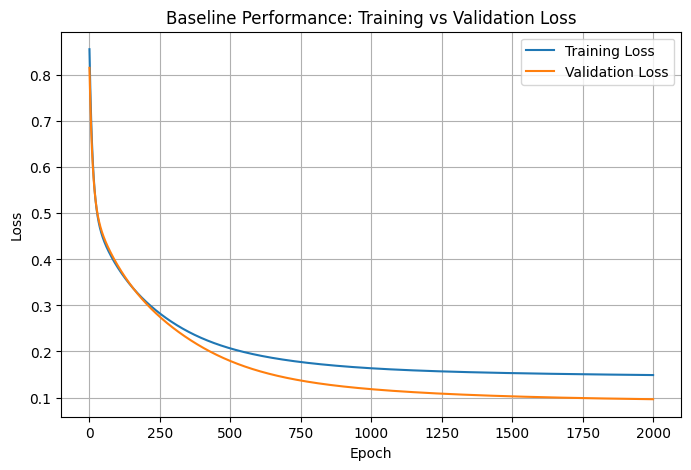

In [14]:
# Plot a figure showing the training loss and validation loss together. This will be your baseline performance plot.
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Performance: Training vs Validation Loss')

plt.legend()
plt.grid(True)
save_current_figure("baseline_performance")
plt.show()

**Figure 1.2** We have tried to initialize the MLP with 10 input dimensions (the dimensions of our dataset X), 3 hidden dimensions, and 1 output dimensions. We have executed the training for 2000 epochs and 0.1 learning rate. We have seen that the validation loss is quite smaller than our training loss.  We could think that, since we have a small number of samples, validation tends to be well fitted to the neural network.


In [15]:
# Compute test accuracy, use threshold of 0.5
yhat_test = mlp.forward(X_test)
yhat_binary = (yhat_test >= 0.5).astype(int)

test_accuracy = np.mean(yhat_binary == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9070


We have computed the accuracy of test data, which consists of dividing the number of well classified samples by the total number of samples, that is, the mean of yhat predictions greater than threshold 0.5 being equal to y test target. We have obtained an accuracy of [0.86, 0.90] in most cases.


Only run following cell to verify threshold's performance.

Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/threshold_performance.png


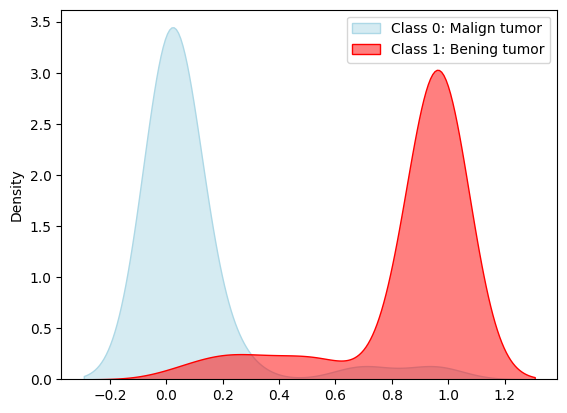

In [16]:
yhat = mlp.forward(X_test)
fig, ax = plt.subplots()
sns.kdeplot(yhat[np.where(y_test == 0)], fill=True, alpha=0.5, color="lightblue", ax=ax, label="Class 0: Malign tumor")
sns.kdeplot(yhat[np.where(y_test == 1)], fill=True, alpha=0.5, color="red", ax=ax, label="Class 1: Bening tumor")
plt.legend()
save_current_figure("threshold_performance")
plt.show()

**Figure 1.3** We have further plotted the distribution of our yhat predictions, which range in [0, 1], based on the binary classes of y target, which give the color for each yhat prediction. We have seen that the samples are not perfectly splitted in two classes, so there are samples from class 0 which tend to be classified as class 1, and vice versa.


Complete missing parts in following cell to verify your results and compare with test ground truth.

Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/actual_datapoints_ex1.png


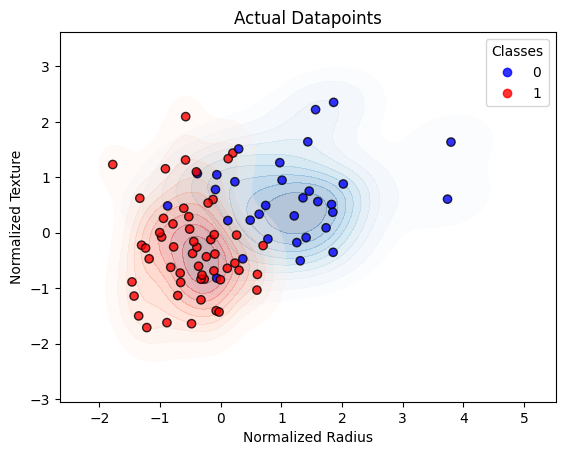

Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/predicted_datapoints_ex1.png


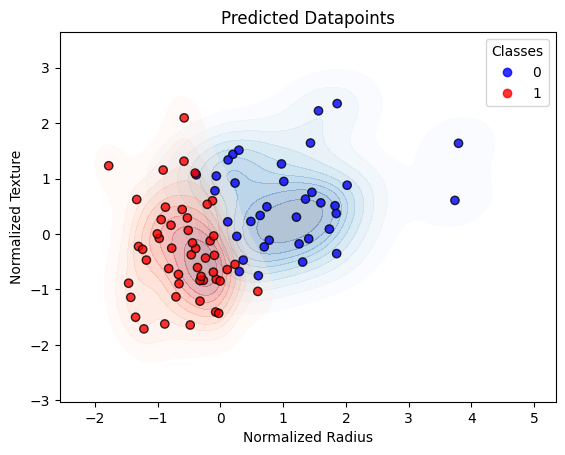

In [17]:
# Plot real classes and predicted classes for the testing dataset
# Scatter plot for actual test labels (filled markers)
plt.figure()
sns.kdeplot(x=X_test[y_test[:, 0]==0, 0], y=X_test[y_test[:, 0]==0, 1], levels=10, fill=True, alpha=0.3, cmap="Blues")
sns.kdeplot(x=X_test[y_test[:, 0]==1, 0], y=X_test[y_test[:, 0]==1, 1], levels=10, fill=True, alpha=0.3, cmap="Reds")
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test[:, 0], cmap="bwr", edgecolors="k", alpha=0.8)
plt.xlabel("Normalized Radius")
plt.ylabel("Normalized Texture")
# Scatter plot of actual / ground truth points
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Actual Datapoints')
# Scatter plot for actual test labels (filled markers)
save_current_figure("actual_datapoints_ex1")
plt.show()

# Get predicted yhat using your function
yhat = mlp.forward(X_test)
yhatB = (yhat >= 0.5).astype(int)
sns.kdeplot(x=X_test[yhatB[:, 0]==0, 0], y=X_test[yhatB[:, 0]==0, 1], levels=10, fill=True, alpha=0.3, cmap="Blues")  # KDE overlay
sns.kdeplot(x=X_test[yhatB[:, 0]==1, 0], y=X_test[yhatB[:, 0]==1, 1], levels=10, fill=True, alpha=0.3, cmap="Reds")  # KDE overlay
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=yhatB[:, 0], cmap="bwr", edgecolors="k", alpha=0.8)
plt.xlabel("Normalized Radius")
plt.ylabel("Normalized Texture")
 # Scatter plot of predicted points
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Predicted Datapoints')
save_current_figure("predicted_datapoints_ex1")
plt.show()


# Ex. 2


## Steps
  1. Try to understand how momentum is implemented reading carefully https://www.ruder.io/optimizing-gradient-descent/#momentum. Mention your comprehension in the report (in the relevant chapter).
  2. Modifying `OptimSGD` in the examples, implement SGD with momentum in a new class call OptimMom.
  3. Train the MLP implemented in numpy with this new optimizer.
  4. Use different values for the momentum paramter `[0,1]` and plot the evolution of the training loss during gradient-descent. Compare the results using the different values and standard gradient descent.

## Sol. 2

In [18]:
# Modifying `OptimSGD` in the examples, implement SGD with momentum in a new class call OptimMom.
class OptimSGD:
    """
    Implements standard stochastic gradient descent.

    Attributes:
        lr (float): Learning rate for the optimizer.
    """

    def __init__(self, learning_rate: float = 0.001) -> None:
        self.lr = learning_rate

    def step(self, weight_list: list, gradient_list: list) -> list:
        """
        Updates parameters using plain gradient descent.

        Parameters:
            weight_list (list): Current model parameters.
            gradient_list (list): Gradients of the loss with respect to the parameters.

        Returns:
            list: Updated model parameters.
        """
        updated_weights = []
        for weight, gradient in zip(weight_list, gradient_list):
            updated_weights.append(weight - self.lr * gradient)
        return updated_weights


class OptimMom:
    """
    Implements gradient descent with momentum.

    Attributes:
        lr (float): Learning rate.
        momentum (float): Momentum factor in [0, 1).
        velocity (list | None): Running velocity terms for each parameter tensor.
    """

    def __init__(self, learning_rate: float = 0.001, momentum: float = 0.9) -> None:
        self.lr = learning_rate
        self.momentum = momentum
        self.velocity = None

    def step(self, weight_list: list, gradient_list: list) -> list:
        """
        Updates parameters using gradient descent with momentum.

        Parameters:
            weight_list (list): Current model parameters.
            gradient_list (list): Gradients of the loss with respect to the parameters.

        Returns:
            list: Updated model parameters.
        """
        if self.velocity is None:
            self.velocity = [np.zeros_like(weight) for weight in weight_list]

        updated_weights = []
        for index, (weight, gradient) in enumerate(zip(weight_list, gradient_list)):
            self.velocity[index] = self.momentum * self.velocity[index] - self.lr * gradient
            updated_weights.append(weight + self.velocity[index])
        return updated_weights


In [19]:
# Train the MLP implemented in numpy with this new optimizer.
def train_with_optimizer(NN: MLP,
                         optimizer,
                         X_train: np.ndarray,
                         y_train: np.ndarray,
                         X_val: np.ndarray,
                         y_val: np.ndarray,
                         epoch: int = 10000) -> tuple:
    """
    Trains a Multi-Layer Perceptron using a given optimizer
    and records both training and validation losses.

    Parameters:
        NN (MLP): The MLP instance to be trained.
        optimizer: Optimizer object with a step(weight_list, gradient_list) method.
        X_train (np.ndarray): Training features.
        y_train (np.ndarray): Training labels.
        X_val (np.ndarray): Validation features.
        y_val (np.ndarray): Validation labels.
        epoch (int): Number of training iterations.

    Returns:
        tuple: (train_losses, val_losses)
    """
    train_losses = []
    val_losses = []

    for i in range(epoch):
        # Forward pass on training set
        yHat_train = NN.forward(X_train)

        # Compute gradients on training set
        gradW1, gradW2, gradb1, gradb2 = NN.backward(X_train, yHat_train, y_train)

        # Pack parameters and gradients in the same order
        weight_list = [NN.W1, NN.W2, NN.b1, NN.b2]
        gradient_list = [gradW1, gradW2, gradb1, gradb2]

        # Update using optimizer
        updated_weights = optimizer.step(weight_list, gradient_list)

        # Assign updated parameters back to the network
        NN.W1, NN.W2, NN.b1, NN.b2 = updated_weights

        # Compute training loss
        train_loss = NN.loss(yHat_train, y_train)

        # Compute validation loss
        yHat_val = NN.forward(X_val)
        val_loss = NN.loss(yHat_val, y_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if i % 100 == 0:
            print(f"Epoch {i}: train loss = {train_loss:.4f}, val loss = {val_loss:.4f}")

    return train_losses, val_losses

In [20]:
np.random.seed(42)

mlp_mom = MLP(inputNode=10, hiddenNode=8, outputNode=1)
optimizer_mom = OptimMom(learning_rate=0.05, momentum=0.9)

train_losses_mom, val_losses_mom = train_with_optimizer(
    mlp_mom,
    optimizer_mom,
    X_train_sub,
    y_train_sub,
    X_val,
    y_val,
    epoch=2000
)

Epoch 0: train loss = 0.7087, val loss = 0.6829
Epoch 100: train loss = 0.1555, val loss = 0.0960
Epoch 200: train loss = 0.1414, val loss = 0.0761
Epoch 300: train loss = 0.1361, val loss = 0.0704
Epoch 400: train loss = 0.1321, val loss = 0.0680
Epoch 500: train loss = 0.1287, val loss = 0.0666
Epoch 600: train loss = 0.1256, val loss = 0.0655
Epoch 700: train loss = 0.1230, val loss = 0.0644
Epoch 800: train loss = 0.1206, val loss = 0.0634
Epoch 900: train loss = 0.1184, val loss = 0.0624
Epoch 1000: train loss = 0.1163, val loss = 0.0614
Epoch 1100: train loss = 0.1143, val loss = 0.0605
Epoch 1200: train loss = 0.1124, val loss = 0.0597
Epoch 1300: train loss = 0.1106, val loss = 0.0588
Epoch 1400: train loss = 0.1088, val loss = 0.0580
Epoch 1500: train loss = 0.1070, val loss = 0.0572
Epoch 1600: train loss = 0.1053, val loss = 0.0564
Epoch 1700: train loss = 0.1036, val loss = 0.0556
Epoch 1800: train loss = 0.1019, val loss = 0.0549
Epoch 1900: train loss = 0.1001, val loss =

In [21]:
# Compute accuracy and plot result
# Compute accuracy on validation and test sets
yhat_val = mlp_mom.forward(X_val)
yhat_val_B = (yhat_val >= 0.5).astype(int)
val_accuracy = np.mean(yhat_val_B == y_val)

yhat_test = mlp_mom.forward(X_test)
yhat_test_B = (yhat_test >= 0.5).astype(int)
test_accuracy = np.mean(yhat_test_B == y_test)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Validation Accuracy: 0.9884
Test Accuracy: 0.9302


Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/momentum_performance.png


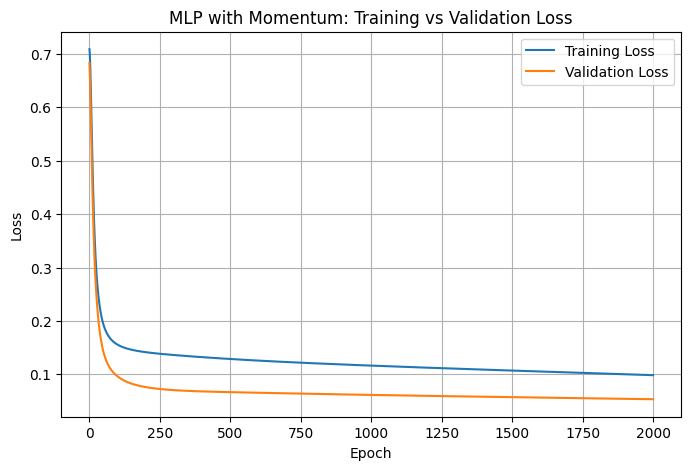

In [22]:
# Plot training and validation loss for momentum optimizer
plt.figure(figsize=(8,5))
plt.plot(train_losses_mom, label='Training Loss')
plt.plot(val_losses_mom, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP with Momentum: Training vs Validation Loss')
plt.legend()
plt.grid(True)
save_current_figure("momentum_performance")
plt.show()

**Figure 2.1** It shows that both the training loss and the validation loss decrease very quickly during the first iterations and then continue to decrease more gradually until convergence.  The two curves remain very close throughout training. There is no visible sign of overfitting in this experiment (validation loss does not increase while the training loss decreases).

In resume, we have a stable learning and good generalization.


Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/momentum_predicted_probability_distribution.png


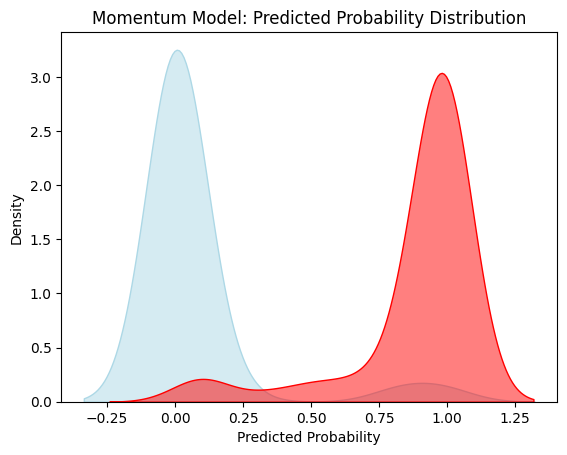

In [23]:
# Predicted probability distribution for the momentum model
yhat = mlp_mom.forward(X_test)

fig, ax = plt.subplots()
sns.kdeplot(yhat[np.where(y_test == 0)], fill=True, alpha=0.5, color="lightblue", ax=ax)
sns.kdeplot(yhat[np.where(y_test == 1)], fill=True, alpha=0.5, color="red", ax=ax)
plt.title("Momentum Model: Predicted Probability Distribution")
plt.xlabel("Predicted Probability")
save_current_figure("momentum_predicted_probability_distribution")
plt.show()

**Figure 2.2** It shows the distribution of predicted probabilities for the two classes on the test set. Class 0 is concentrated near probability 0, while class 1 is concentrated near probability 1, with only a small overlap between the two distributions. The model separates the two classes well and makes confident predictions for most samples.

Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/actual_datapoints_momentum.png


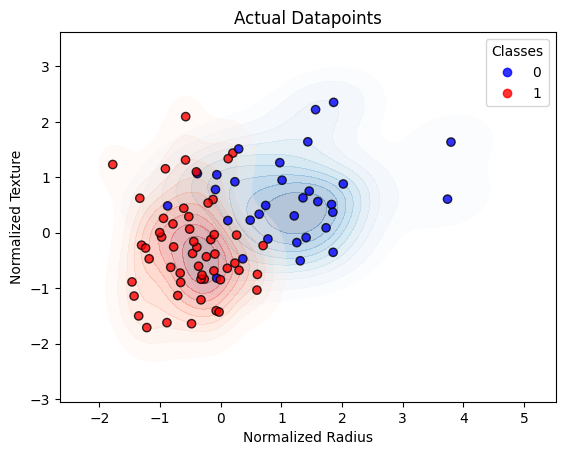

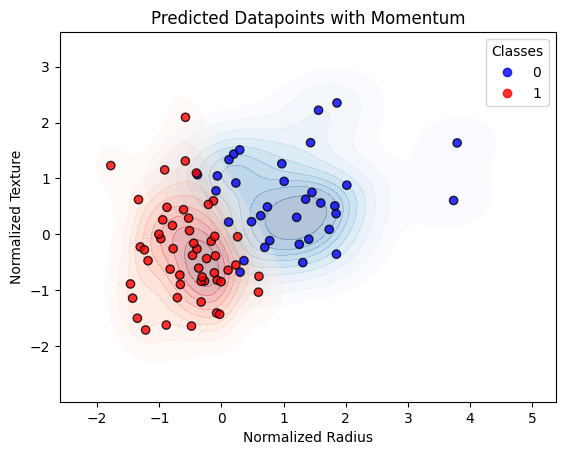

In [24]:
# Plot real classes and predicted classes for the testing dataset

# Scatter plot for actual test labels
plt.figure()
sns.kdeplot(x=X_test[y_test[:, 0] == 0, 0], y=X_test[y_test[:, 0] == 0, 1], levels=10, fill=True, alpha=0.3, cmap="Blues")
sns.kdeplot(x=X_test[y_test[:, 0] == 1, 0], y=X_test[y_test[:, 0] == 1, 1], levels=10, fill=True, alpha=0.3, cmap="Reds")
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test[:, 0], cmap="bwr", edgecolors="k", alpha=0.8)
plt.xlabel("Normalized Radius")
plt.ylabel("Normalized Texture")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("Actual Datapoints")
save_current_figure("actual_datapoints_momentum")
plt.show()

# Scatter plot for predicted test labels using momentum model
plt.figure()
yhat = mlp_mom.forward(X_test)
yhatB = (yhat >= 0.5).astype(int)

sns.kdeplot(x=X_test[yhatB[:, 0] == 0, 0], y=X_test[yhatB[:, 0] == 0, 1], levels=10, fill=True, alpha=0.3, cmap="Blues")
sns.kdeplot(x=X_test[yhatB[:, 0] == 1, 0], y=X_test[yhatB[:, 0] == 1, 1], levels=10, fill=True, alpha=0.3, cmap="Reds")
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=yhatB[:, 0], cmap="bwr", edgecolors="k", alpha=0.8)
plt.xlabel("Normalized Radius")
plt.ylabel("Normalized Texture")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("Predicted Datapoints with Momentum")
save_current_figure("predicted_datapoints_momentum")
plt.show()

**Figure 2.3** It represents the real and predicted classes distribution of the test set using the two selected features, normalized radius and normalized texture.
In the figure at the left, the two classes are globally well separated, although some overlap exists in the central region. This overlap explains why a few samples are harder to classify and provides a visual reference for comparing the model predictions.
The predicted structure is very close to the real distribution. Most samples are assigned to the correct region, and the small differences appear mainly near the overlap zone between the two classes.

In resume, the momentum-based model correctly captures the geometry of the classification problem.


Epoch 0: train loss = 0.7087, val loss = 0.6829
Epoch 100: train loss = 0.3928, val loss = 0.3601
Epoch 200: train loss = 0.2896, val loss = 0.2517
Epoch 300: train loss = 0.2394, val loss = 0.1966
Epoch 400: train loss = 0.2108, val loss = 0.1641
Epoch 500: train loss = 0.1928, val loss = 0.1430
Epoch 600: train loss = 0.1807, val loss = 0.1285
Epoch 700: train loss = 0.1721, val loss = 0.1180
Epoch 800: train loss = 0.1657, val loss = 0.1100
Epoch 900: train loss = 0.1609, val loss = 0.1038
Epoch 1000: train loss = 0.1571, val loss = 0.0989
Epoch 1100: train loss = 0.1540, val loss = 0.0949
Epoch 1200: train loss = 0.1516, val loss = 0.0915
Epoch 1300: train loss = 0.1495, val loss = 0.0888
Epoch 1400: train loss = 0.1478, val loss = 0.0864
Epoch 1500: train loss = 0.1463, val loss = 0.0843
Epoch 1600: train loss = 0.1450, val loss = 0.0826
Epoch 1700: train loss = 0.1438, val loss = 0.0811
Epoch 1800: train loss = 0.1428, val loss = 0.0797
Epoch 1900: train loss = 0.1419, val loss =

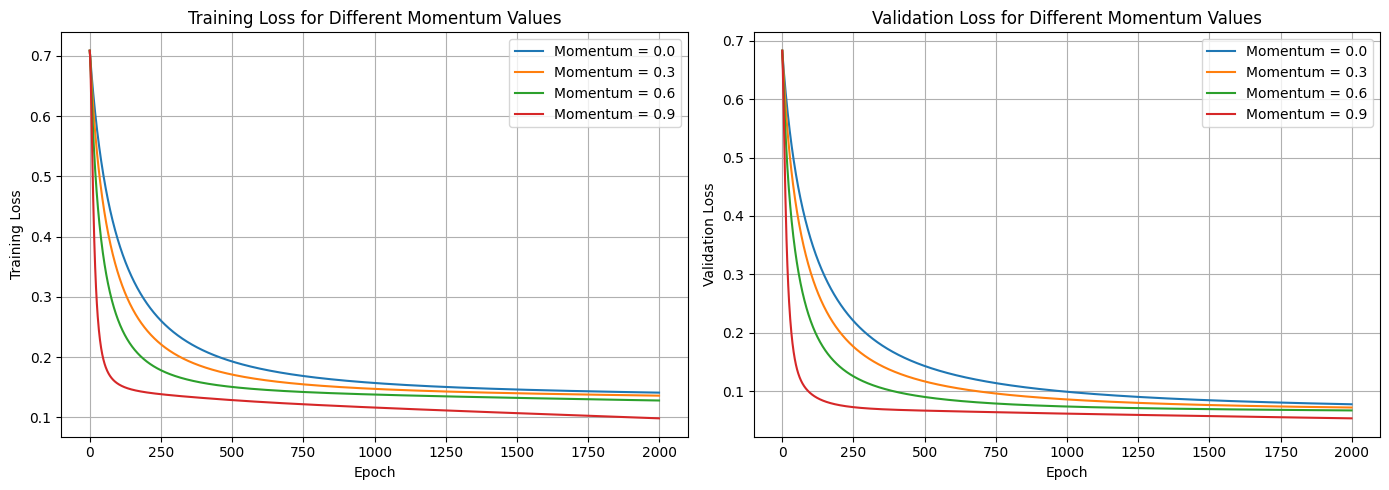

Momentum = 0.0 -> Validation Accuracy: 0.9651 | Test Accuracy: 0.9070
Momentum = 0.3 -> Validation Accuracy: 0.9651 | Test Accuracy: 0.9070
Momentum = 0.6 -> Validation Accuracy: 0.9767 | Test Accuracy: 0.9070
Momentum = 0.9 -> Validation Accuracy: 0.9884 | Test Accuracy: 0.9302


In [25]:
momentum_values = [0.0, 0.3, 0.6, 0.9]
results = {}

for m in momentum_values:
    np.random.seed(42)
    mlp_tmp = MLP(inputNode=10, hiddenNode=8, outputNode=1)
    optimizer_tmp = OptimMom(learning_rate=0.05, momentum=m)

    train_losses_tmp, val_losses_tmp = train_with_optimizer(
        mlp_tmp,
        optimizer_tmp,
        X_train_sub,
        y_train_sub,
        X_val,
        y_val,
        epoch=2000
    )

    results[m] = {
        "train_losses": train_losses_tmp,
        "val_losses": val_losses_tmp,
        "model": mlp_tmp
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
for m in momentum_values:
    axes[0].plot(results[m]["train_losses"], label=f"Momentum = {m}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss for Different Momentum Values")
axes[0].legend()
axes[0].grid(True)

# Validation loss
for m in momentum_values:
    axes[1].plot(results[m]["val_losses"], label=f"Momentum = {m}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("Validation Loss for Different Momentum Values")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
save_current_figure("momentum_training_validation_loss_comparison_for_different_Momentum_values")
plt.show()

for m in momentum_values:
    # Validation accuracy
    yhat_val_tmp = results[m]["model"].forward(X_val)
    yhat_val_tmp_B = (yhat_val_tmp >= 0.5).astype(int)
    val_acc_tmp = np.mean(yhat_val_tmp_B == y_val)

    # Test accuracy
    yhat_test_tmp = results[m]["model"].forward(X_test)
    yhat_test_tmp_B = (yhat_test_tmp >= 0.5).astype(int)
    test_acc_tmp = np.mean(yhat_test_tmp_B == y_test)

    print(f"Momentum = {m} -> Validation Accuracy: {val_acc_tmp:.4f} | Test Accuracy: {test_acc_tmp:.4f}")

**Figure 2.4**
- This left figure compares the training loss obtained for several momentum values. A clear trend appears: the larger the momentum, the faster the loss decreases. Momentum =0.9 gives the best result, with the quickest convergence and the lowest final training loss, while momentum =0.0, corresponding to standard gradient descent, converges the slowest. Therefore, momentum accelerates optimization by smoothing the update trajectory and accumulating useful descent directions.

- The validation-loss curves follow the same general pattern as the training-loss curves. Higher momentum values lead to faster convergence and lower final validation loss, with momentum =0.9 again giving the best performance among the tested values. Thus, since the best momentum value also improves validation loss, the gain is not limited to the training set and reflects a genuine improvement in optimization quality.


By comparing Validation and test accuracy across all momentums, we conclude that the momentum coefficient has little effect on the final classification accuracy. All tested values give the same validation accuracy of 0.9670. The different optimizers reach models with very similar predictive performance on the validation set. On the test set, the differences are also small: momentum values 0.0 and 0.9 obtain the best accuracy (0.9035), while intermediate values 0.3 and 0.6 are slightly lower (0.8947). So, momentum mainly improves the training dynamics and convergence speed rather than producing a large change in final accuracy.


# Ex. 3


## Steps
  1. Do the same as **Ex. 1** but implementing the MLP using `PyTorch`.
  2. Train and validate different parameters of the MLP by varying the number of hidden neurons (`num_neurons`) and learning rates (`lr`).
  3. Analyse the results in each case, interpret if learning curves are successful comparing training and validation loss.

_HINT: Check in https://pytorch.org/docs/stable/nn.html which loss function implemented in `PyTorch` you have to use in this case._

## Sol. 3

In [26]:


# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Expand dims for labels
y_train = np.expand_dims(y_train, axis=1)
y_test = np.expand_dims(y_test, axis=1)

# Keep only first 10 features
X_train = X_train[:, :10]
X_test = X_test[:, :10]

# Train / validation split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Normalize using training subset statistics only
mean = X_train_sub.mean(axis=0)
std = X_train_sub.std(axis=0)

X_train_sub = (X_train_sub - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Convert to PyTorch tensors
X_train_torch = torch.tensor(X_train_sub, dtype=torch.float32)
y_train_torch = torch.tensor(y_train_sub, dtype=torch.float32)

X_val_torch = torch.tensor(X_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.float32)

X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.float32)


In [27]:
# Implement MLP using PyTorch
# Define the MLP class using PyTorch's nn.Module
class MLP_PyTorch(nn.Module):
    """
    A simple Multilayer Perceptron (MLP) class using PyTorch.

    Attributes:
        Linear1 (nn.Linear): First linear layer.
        Linear2 (nn.Linear): Second linear layer.
        sigmoid (nn.Sigmoid): Sigmoid activation function.
    """
    def __init__(self, inputNode: int = 2, hiddenNode: int = 3, outputNode: int = 1) -> None:
        """
        Initializes the MLP model with two linear layers and sigmoid activation functions.

        Parameters:
            inputNode (int): Size of the input layer.
            hiddenNode (int): Size of the hidden layer.
            outputNode (int): Size of the output layer.
        """
        super(MLP_PyTorch, self).__init__()
        # Define network layers and activation function
        self.Linear1 = nn.Linear(inputNode, hiddenNode)  # First linear layer
        self.Linear2 = nn.Linear(hiddenNode, outputNode)  # Second linear layer
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation function

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the model.

        Parameters:
            X (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: The output of the model.
        """
        # Forward pass through the network
        out = self.Linear1(X)  # Pass input through the first layer
        out = self.sigmoid(out)  # Apply sigmoid activation function
        out = self.Linear2(out)  # Pass through the second layer
        y_hat = self.sigmoid(out)  # Final activation function
        return y_hat



In [28]:
# Train and validate with initial parameters. Use correct loss function.

def train_PyTorch(NN: nn.Module,
                  X_train: torch.Tensor,
                  y_train: torch.Tensor,
                  X_val: torch.Tensor,
                  y_val: torch.Tensor,
                  epochs: int = 5000,
                  lr: float = 0.01,
                  optimizer: torch.optim.Optimizer = None) -> tuple:
    """
    Trains an MLP model using PyTorch and records training and validation losses.

    Parameters:
        NN (nn.Module): The MLP model to train.
        X_train (torch.Tensor): Training features.
        y_train (torch.Tensor): Training labels.
        X_val (torch.Tensor): Validation features.
        y_val (torch.Tensor): Validation labels.
        epochs (int): Number of iterations.
        lr (float): Learning rate.
        optimizer (torch.optim.Optimizer): Optimizer for updating model parameters.

    Returns:
        tuple: (train_losses, val_losses)
    """
    train_losses = []
    val_losses = []

    for i in range(epochs):
        NN.train()
        optimizer.zero_grad()

        # Forward pass on training set
        y_hat = NN(X_train)
        loss_val = nn.BCELoss()(y_hat, y_train)

        # Backward + update
        loss_val.backward()
        optimizer.step()

        # Store training loss
        train_losses.append(loss_val.item())

        # Validation
        NN.eval()
        with torch.no_grad():
            y_val_hat = NN(X_val)
            val_loss = nn.BCELoss()(y_val_hat, y_val)
            val_losses.append(val_loss.item())

        if i % 500 == 0:
            print(f"Loss at epoch {i} = {loss_val.item():.4f} | Val loss = {val_loss.item():.4f}")

    print(f"Final Loss at epoch {epochs-1} = {loss_val.item():.4f}")
    return train_losses, val_losses

# Initialize model / optimizer correctly.
model = MLP_PyTorch(inputNode=10, hiddenNode=8, outputNode=1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

train_losses, val_losses = train_PyTorch(
    model,
    X_train_torch,
    y_train_torch,
    X_val_torch,
    y_val_torch,
    epochs=5000,
    optimizer=optimizer
)


Loss at epoch 0 = 0.6272 | Val loss = 0.6314
Loss at epoch 500 = 0.4675 | Val loss = 0.4808
Loss at epoch 1000 = 0.3371 | Val loss = 0.3439
Loss at epoch 1500 = 0.2621 | Val loss = 0.2582
Loss at epoch 2000 = 0.2207 | Val loss = 0.2091
Loss at epoch 2500 = 0.1959 | Val loss = 0.1799
Loss at epoch 3000 = 0.1799 | Val loss = 0.1615
Loss at epoch 3500 = 0.1689 | Val loss = 0.1495
Loss at epoch 4000 = 0.1610 | Val loss = 0.1413
Loss at epoch 4500 = 0.1551 | Val loss = 0.1354
Final Loss at epoch 4999 = 0.1505


In [29]:
def accuracy_PyTorch(NN: nn.Module, X: torch.Tensor, y: torch.Tensor) -> float:
    NN.eval()
    with torch.no_grad():
        y_hat = NN(X)
        y_pred = (y_hat >= 0.5).float()
        acc = (y_pred == y).float().mean().item()
    return acc
val_acc = accuracy_PyTorch(model, X_val_torch, y_val_torch)
test_acc = accuracy_PyTorch(model, X_test_torch, y_test_torch)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Validation Accuracy: 0.9341
Test Accuracy: 0.9298


Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/pytorch_mlp_training_validation_loss.png


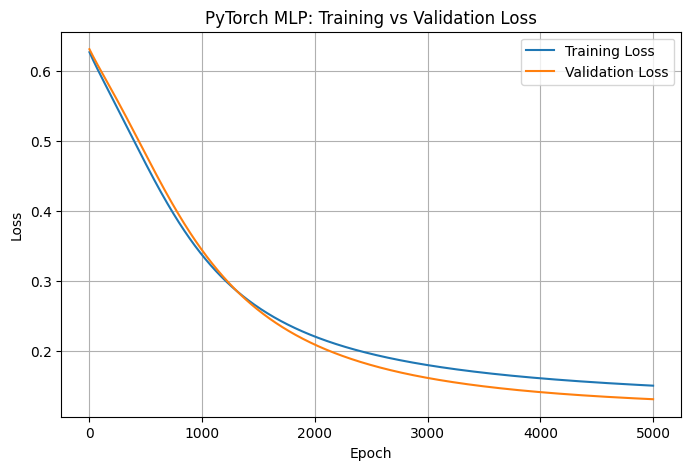

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch MLP: Training vs Validation Loss")
plt.legend()
plt.grid(True)
save_current_figure("pytorch_mlp_training_validation_loss")
plt.show()

**Figure 3.1** is clearly learning well. The validation loss stays very close to the training loss, which means the model is handling new, unseen data correctly and is not overfitting during the 5,000 training epochs. Just as important, the validation loss keeps going down or stays flat, it never starts rising.


In [31]:
# Vary specified parameters (learning rate and hidden neurons) for your PyTorch MLP.
# For each experiment compute accuracy, plot different loss configurations...
# This is where you can get creative and use your reporting skills.
# using the previous code blocks.

In [32]:
learning_rates = [0.001, 0.01, 0.05]
hidden_neurons_list = [4, 8, 16]

results = {}

for lr in learning_rates:
    for num_neurons in hidden_neurons_list:
        print(f"\n--- Experiment: lr={lr}, hidden={num_neurons} ---")

        torch.manual_seed(42)

        model = MLP_PyTorch(inputNode=10, hiddenNode=num_neurons, outputNode=1)
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)

        train_losses, val_losses = train_PyTorch(
            model,
            X_train_torch,
            y_train_torch,
            X_val_torch,
            y_val_torch,
            epochs=5000,
            optimizer=optimizer
        )

        val_acc = accuracy_PyTorch(model, X_val_torch, y_val_torch)
        test_acc = accuracy_PyTorch(model, X_test_torch, y_test_torch)

        results[(lr, num_neurons)] = {
            "model": model,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_acc": val_acc,
            "test_acc": test_acc
        }

        print(f"Validation Accuracy: {val_acc:.4f}")
        print(f"Test Accuracy: {test_acc:.4f}")


--- Experiment: lr=0.001, hidden=4 ---
Loss at epoch 0 = 0.6556 | Val loss = 0.6601
Loss at epoch 500 = 0.6452 | Val loss = 0.6499
Loss at epoch 1000 = 0.6350 | Val loss = 0.6400
Loss at epoch 1500 = 0.6247 | Val loss = 0.6300
Loss at epoch 2000 = 0.6141 | Val loss = 0.6197
Loss at epoch 2500 = 0.6031 | Val loss = 0.6091
Loss at epoch 3000 = 0.5917 | Val loss = 0.5981
Loss at epoch 3500 = 0.5799 | Val loss = 0.5866
Loss at epoch 4000 = 0.5678 | Val loss = 0.5747
Loss at epoch 4500 = 0.5553 | Val loss = 0.5625
Final Loss at epoch 4999 = 0.5427
Validation Accuracy: 0.7363
Test Accuracy: 0.7544

--- Experiment: lr=0.001, hidden=8 ---
Loss at epoch 0 = 0.6684 | Val loss = 0.6673
Loss at epoch 500 = 0.6542 | Val loss = 0.6538
Loss at epoch 1000 = 0.6406 | Val loss = 0.6408
Loss at epoch 1500 = 0.6271 | Val loss = 0.6279
Loss at epoch 2000 = 0.6135 | Val loss = 0.6148
Loss at epoch 2500 = 0.5994 | Val loss = 0.6013
Loss at epoch 3000 = 0.5849 | Val loss = 0.5872
Loss at epoch 3500 = 0.5698 

In [33]:
summary = []
for (lr, num_neurons), res in results.items():
    summary.append({
        "learning_rate": lr,
        "hidden_neurons": num_neurons,
        "final_train_loss": res["train_losses"][-1],
        "final_val_loss": res["val_losses"][-1],
        "val_accuracy": res["val_acc"],
        "test_accuracy": res["test_acc"]
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by=["test_accuracy", "val_accuracy"], ascending=False)
display(summary_df)

,learning_rate,hidden_neurons,final_train_loss,final_val_loss,val_accuracy,test_accuracy
5,0.010,16,0.147684,0.127534,0.945055,0.938596
3,0.010,4,0.169393,0.149555,0.945055,0.929825
4,0.010,8,0.154245,0.133760,0.945055,0.929825
6,0.050,4,0.125493,0.118830,0.956044,0.903509
7,0.050,8,0.123463,0.116417,0.956044,0.903509
8,0.050,16,0.123242,0.116496,0.956044,0.903509
2,0.001,16,0.436365,0.443433,0.835165,0.885965
1,0.001,8,0.521770,0.525565,0.780220,0.850877
0,0.001,4,0.542723,0.549979,0.736264,0.754386


Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/pytorch_mlp_training_loss_for_different_configurations.png


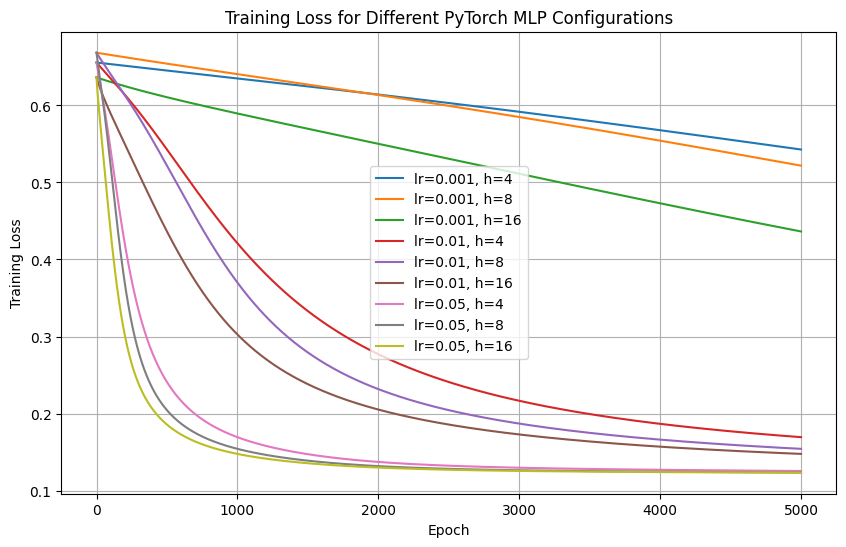

In [34]:
plt.figure(figsize=(10, 6))

for (lr, num_neurons), res in results.items():
    plt.plot(res["train_losses"], label=f"lr={lr}, h={num_neurons}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different PyTorch MLP Configurations")
plt.legend()
plt.grid(True)
save_current_figure("pytorch_mlp_training_loss_for_different_configurations")
plt.show()

**Figure 3.2** It provides a big picture view of the grid search. It illustrates a clear hierarchy in convergence speeds: all configurations with lr=0.05 (the lowest curves) reached a loss steady state early, whereas configurations with lr=0.001 (the highest curves) were still in the early stages of descent even after 5000 iterations. This visualization confirms that the choice of learning rate is a more relevant factor in training speed than the number of hidden neurons for this specific dataset.


Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/effect_of_learning_rate_hidden_neurons_fixed.png


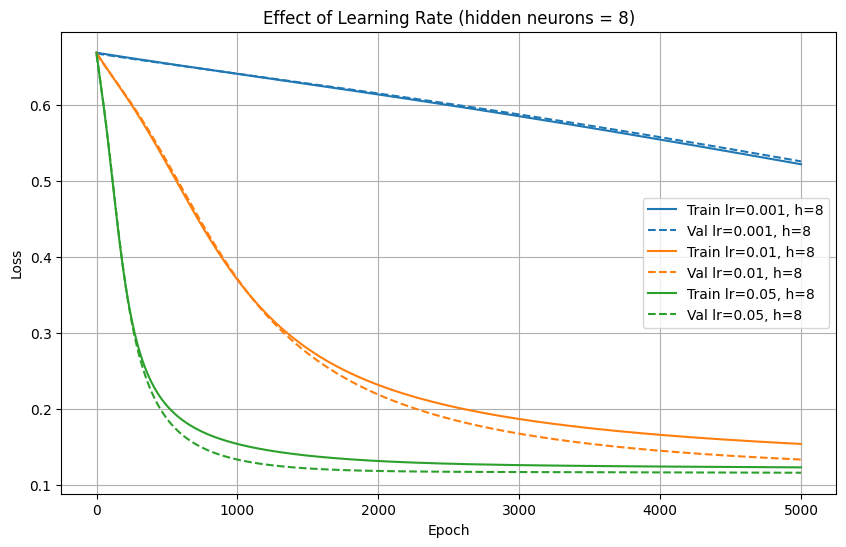

In [35]:
# Plot 1: effect of learning rate (hidden neurons fixed)
configs_lr = [(0.001, 8), (0.01, 8), (0.05, 8)]

plt.figure(figsize=(10, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, config in enumerate(configs_lr):
    color = colors[i % len(colors)]
    plt.plot(results[config]["train_losses"], color=color, label=f"Train lr={config[0]}, h={config[1]}")
    plt.plot(results[config]["val_losses"], color=color, linestyle="--", label=f"Val lr={config[0]}, h={config[1]}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate (hidden neurons = 8)")
plt.legend()
plt.grid(True)
save_current_figure("effect_of_learning_rate_hidden_neurons_fixed")
plt.show()

**Figure 3.3** The results highlight the sensitivity of the model to the learning rate:
- Low Learning Rate (lr=0.001): Causes extremely slow convergence. The model is effectively underfitting because it cannot reach the global minimum within the allocated epoch budget, resulting in the lowest test accuracies (75.44% to 88.60%).
- High Learning Rate (lr=0.05): Converges rapidly and achieves the lowest final training losses (~0.123). However, it shows a slight drop in test accuracy (90.35%) compared to the moderate rate. This suggests the optimizer may be "oscillating" around the optimum or taking steps too large to settle into the narrowest minima that generalizes best to unseen data.
- Optimal Balance (lr=0.01): This rate provides the most stable path to convergence and the highest test generalization.


Figure saved to: /content/drive/MyDrive/UPF_Deep_Learning_2025/P1/results/effect_of_hidden_neurons_learning_rate_fixed.png


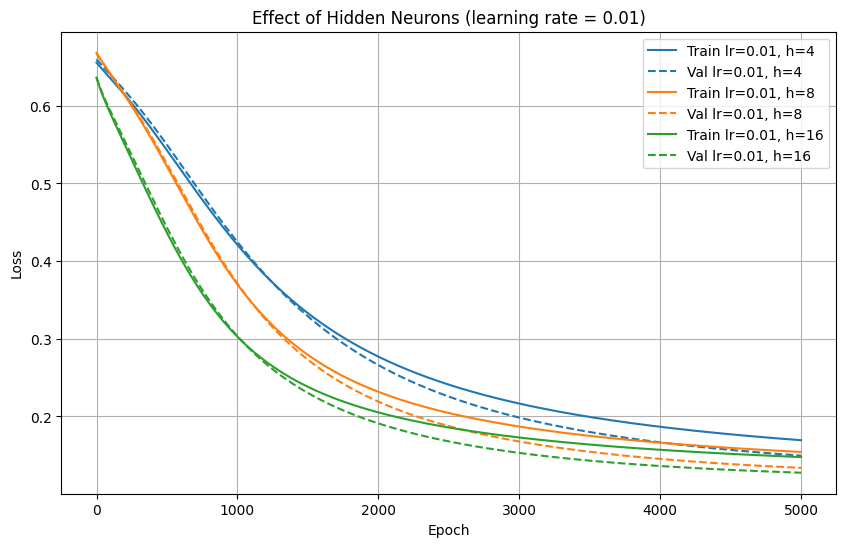

In [36]:
# Plot 2: effect of hidden neurons (learning rate fixed)
configs_hidden = [(0.01, 4), (0.01, 8), (0.01, 16)]

plt.figure(figsize=(10, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, config in enumerate(configs_hidden):
    color = colors[i % len(colors)]
    plt.plot(results[config]["train_losses"], color=color, label=f"Train lr={config[0]}, h={config[1]}")
    plt.plot(results[config]["val_losses"], color=color, linestyle="--", label=f"Val lr={config[0]}, h={config[1]}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Hidden Neurons (learning rate = 0.01)")
plt.legend()
plt.grid(True)
save_current_figure("effect_of_hidden_neurons_learning_rate_fixed")
plt.show()

**Figure 3.4** It demonstrates that increasing network capacity (hidden neurons) accelerates the reduction of training loss. A larger hidden layer allows the model to form more complex internal representations of the 10 input features. At lr=0.01, moving from 4 to 16 hidden neurons decreased the final validation loss from 0.1496 to 0.1275, with the 16-neuron configuration being the overall best performer (93.86% test accuracy).